# PhotoMaker V2 — Baseline Generation on LFW

**Course Project — Image Processing**
**Federal University of Maranhão (UFMA) — CCET**

Authors: Louise Reis Mendes, Raianny Cristina Ferreira da Silva, Yasmin Cantanhede Santos, Haroldo Gomes

---

## Purpose

This notebook reproduces **PhotoMaker** (Li et al., 2023), the **second baseline** compared in
the Arc2Face paper (Table 1). We use **PhotoMaker-V2**, the improved release that combines a
stacked-ID image embedding with an InsightFace identity embedding for stronger face fidelity.

It runs on the **same 50 LFW identities** used for Arc2Face and IP-Adapter-FaceID-PlusV2, so
the three-way comparison is fair.

## How PhotoMaker works

PhotoMaker encodes one or more reference images of a person into a "stacked ID embedding" and
injects it into an SDXL backbone at a chosen diffusion step (`start_merge_step`). A trigger
word (`img`) in the prompt marks where the identity should be applied. PhotoMaker-V2
additionally uses an InsightFace embedding (`id_embeds`) to reinforce identity.

## Notes on this reproduction

- **Do not `pip install photomaker`** from PyPI — that name belongs to an unrelated package.
  We install the official code from the TencentARC GitHub repository instead.
- We use the repository's own `FaceAnalysis2` / `analyze_faces` helpers, which automatically
  lower the detection size until a face is found — useful for the small, unconstrained LFW
  images.
- Generated images are centered face close-ups at 1024×1024. This matches the evaluation
  protocol of the Arc2Face paper, where all methods produce centered face crops so that
  identity metrics are comparable.

> **Hardware:** NVIDIA A100 GPU recommended. Runtime → Change runtime type → A100 GPU.

## 1. Dependency Installation

Pinned versions for reproducibility. `transformers` and `peft` use `--no-deps` to avoid
incompatible upgrades in the Colab environment.

In [ ]:
!pip install -q diffusers==0.29.2
!pip install -q transformers==4.36.0 --no-deps
!pip install -q tokenizers==0.15.2 safetensors==0.4.1 huggingface_hub
!pip install -q peft==0.9.0 --no-deps
!pip install -q accelerate
!pip install -q insightface onnxruntime

import torch
print(f'GPU: {torch.cuda.get_device_name(0)}')
print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 97.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.8/126.8 kB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 162.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 121.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 80.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 52.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sentence-transformers 5.6.0 requires transformers<6.0.0,>=4.41.0, but you have transformers 4.36.0 which is incompatible.
accelerate 1.14.0 requires safetensors>=0.4.3, but you have safetensors 0.4.1 which is incompatible.
gradio 6.19.0 requires huggingface-hub<2.0,>=1.2.0, but you have huggingface-hub 0.36.2 which is incompatible.
   ━━━━━━━━━━━━━━━━

## 2. Install PhotoMaker from the Official Repository

We clone the TencentARC repository and install it in editable mode. This is the reliable way
to import `PhotoMakerStableDiffusionXLPipeline`, `FaceAnalysis2` and `analyze_faces` (the PyPI
package called `photomaker` is a different, unrelated project).

In [ ]:
import os, sys

!git clone https://github.com/TencentARC/PhotoMaker.git
sys.path.insert(0, '/content/PhotoMaker')

%cd /content/PhotoMaker
!pip install -q -e .
%cd /content

from photomaker import PhotoMakerStableDiffusionXLPipeline, FaceAnalysis2, analyze_faces
print('PhotoMaker imported successfully.')

Cloning into 'PhotoMaker'...
remote: Enumerating objects: 306, done.
remote: Counting objects: 100% (150/150), done.
remote: Compressing objects: 100% (97/97), done.
remote: Total 306 (delta 132), reused 53 (delta 53), pack-reused 156 (from 2)
Receiving objects: 100% (306/306), 10.24 MiB | 23.34 MiB/s, done.
Resolving deltas: 100% (164/164), done.
/content/PhotoMaker
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for photomaker (pyproject.toml) ... done
/content


/usr/local/lib/python3.12/dist-packages/transformers/utils/generic.py:441: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
/usr/local/lib/python3.12/dist-packages/transformers/utils/generic.py:309: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
/usr/local/lib/python3.12/dist-packages/transformers/utils/generic.py:309: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(


PhotoMaker imported successfully.


## 3. Configure Face Detector and Download PhotoMaker-V2 Weights

`FaceAnalysis2` is the repository's detector wrapper; `analyze_faces` retries with smaller
detection sizes until a face is found. We then download the PhotoMaker-V2 checkpoint.

In [ ]:
import numpy as np
from diffusers.utils import load_image
from diffusers import EulerDiscreteScheduler
from huggingface_hub import hf_hub_download

face_detector = FaceAnalysis2(
    providers=['CUDAExecutionProvider', 'CPUExecutionProvider'],
    allowed_modules=['detection', 'recognition']
)
face_detector.prepare(ctx_id=0, det_size=(640, 640))

photomaker_ckpt = hf_hub_download(
    repo_id='TencentARC/PhotoMaker-V2',
    filename='photomaker-v2.bin',
    repo_type='model'
)
print(f'PhotoMaker-V2 checkpoint: {photomaker_ckpt}')

download_path: /root/.insightface/models/buffalo_l


100%|██████████| 281857/281857 [00:02<00:00, 108006.37KB/s]
/usr/local/lib/python3.12/dist-packages/onnxruntime/capi/onnxruntime_inference_collection.py:147: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(


Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
model ignore: /root/.insightface/models/buffalo_l/1k3d68.onnx landmark_3d_68
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
model ignore: /root/.insightface/models/buffalo_l/2d106det.onnx landmark_2d_106
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/det_10g.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
model ignore: /root/.insightface/models/buffalo_l/genderage.onnx genderage
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/w600k_r50.onnx recognition ['None', 3, 112, 112] 127.5 127.5
set det-size: (640, 640)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


photomaker-v2.bin:   0%|          | 0.00/1.80G [00:00<?, ?B/s]

PhotoMaker-V2 checkpoint: /root/.cache/huggingface/hub/models--TencentARC--PhotoMaker-V2/snapshots/f5a1e5155dc02166253fa7e29d13519f5ba22eac/photomaker-v2.bin


## 4. Build the PhotoMaker Pipeline

We load the `RealVisXL_V4.0` SDXL base model, attach the PhotoMaker adapter with the trigger
word `img`, fuse its LoRA weights, and switch to the Euler scheduler.

In [ ]:
pipe = PhotoMakerStableDiffusionXLPipeline.from_pretrained(
    'SG161222/RealVisXL_V4.0',
    torch_dtype=torch.float16
).to('cuda')

pipe.load_photomaker_adapter(
    os.path.dirname(photomaker_ckpt),
    subfolder='',
    weight_name=os.path.basename(photomaker_ckpt),
    trigger_word='img'
)

pipe.fuse_lora()
pipe.scheduler = EulerDiscreteScheduler.from_config(pipe.scheduler.config)
print('PhotoMaker V2 pipeline ready.')

model_index.json:   0%|          | 0.00/577 [00:00<?, ?B/s]

Fetching 18 files:   0%|          | 0/18 [00:00<?, ?it/s]

config.json:   0%|          | 0.00/560 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

config.json:   0%|          | 0.00/602 [00:00<?, ?B/s]

unet/diffusion_pytorch_model.safetensors:   0%|          | 0.00/10.3G [00:00<?, ?B/s]

vae/diffusion_pytorch_model.safetensors:   0%|          | 0.00/335M [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading PhotoMaker v2 components [1] id_encoder from [/root/.cache/huggingface/hub/models--TencentARC--PhotoMaker-V2/snapshots/f5a1e5155dc02166253fa7e29d13519f5ba22eac]...
4096
Loading PhotoMaker v2 components [2] lora_weights from [/root/.cache/huggingface/hub/models--TencentARC--PhotoMaker-V2/snapshots/f5a1e5155dc02166253fa7e29d13519f5ba22eac]
PhotoMaker V2 pipeline ready.


## 5. Load the Same 50 LFW Identities

We read the frozen identity list produced by the Arc2Face notebook and copy each reference
image locally, ensuring all three models use identical inputs.

In [ ]:
from google.colab import drive
import json, shutil
from pathlib import Path

drive.mount('/content/drive')

DRIVE = '/content/drive/MyDrive/Arc2Face'

with open(f'{DRIVE}/arc2face_processed.json') as f:
    ids_list = json.load(f)

print(f'Identities in JSON: {len(ids_list)}')

os.makedirs('/tmp/inputs_lfw', exist_ok=True)
identity_map = {}
for name in ids_list:
    src = Path(f'{DRIVE}/results_arc2face/{name}/input.jpg')
    dst = Path(f'/tmp/inputs_lfw/{name}.jpg')
    if src.exists():
        shutil.copy(src, dst)
        identity_map[name] = str(dst)

print(f'{len(identity_map)} identities loaded.')
print(f'Examples: {list(identity_map.keys())[:3]}')

Mounted at /content/drive
Identities in JSON: 50
50 identities loaded.
Examples: ['Intisar_Ajouri', 'Norman_Jewison', 'Nick_Nolte']


## 6. Single-Identity Sanity Check

We verify on one identity that the generated face resembles the input before running the full
batch. The ArcFace embedding is extracted with `analyze_faces` and passed as `id_embeds`
alongside the reference image.

Testing: Intisar_Ajouri


  0%|          | 0/50 [00:00<?, ?it/s]

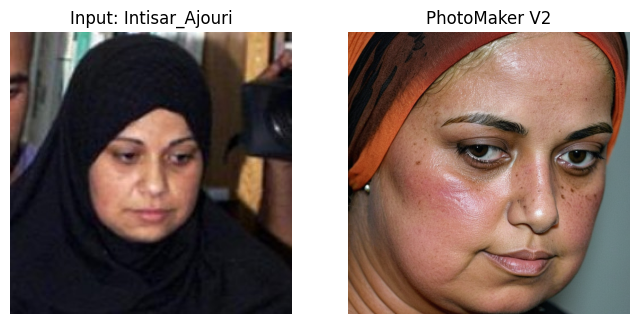

Sanity check done.


In [ ]:
import matplotlib.pyplot as plt

PROMPT = 'photo of a person img, photorealistic, high quality, natural skin'
NEG = '(asymmetry, worst quality, low quality, illustration, 3d, 2d, painting, cartoons, sketch), open mouth'

name = list(identity_map.keys())[0]
img_path = identity_map[name]
print(f'Testing: {name}')

input_image = load_image(img_path)
input_id_images = [input_image]

# Extract ArcFace embedding (BGR order) using the repo's robust detector
img_array = np.array(input_image)[:, :, ::-1]
faces = analyze_faces(face_detector, img_array)
id_embeds = torch.stack([torch.from_numpy(faces[0]['embedding'])])

images = pipe(
    prompt=PROMPT,
    negative_prompt=NEG,
    input_id_images=input_id_images,
    id_embeds=id_embeds,
    num_images_per_prompt=1,
    num_inference_steps=50,
    start_merge_step=10,
).images

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(input_image); axes[0].set_title(f'Input: {name}'); axes[0].axis('off')
axes[1].imshow(images[0]); axes[1].set_title('PhotoMaker V2'); axes[1].axis('off')
plt.show()
print('Sanity check done.')

## 7. Full Generation Loop (50 identities × 5 images)

For each identity we extract the ArcFace embedding and generate 5 images with a fixed
configuration (`num_inference_steps=50`, `start_merge_step=10`). The reference image is copied
into each output folder for the evaluation step.

In [ ]:
from tqdm import tqdm

OUTPUT_PATH = Path('./results/photomaker')
OUTPUT_PATH.mkdir(parents=True, exist_ok=True)
FAILED = []

for name, img_path in tqdm(identity_map.items(), desc='Generating (PhotoMaker V2)'):
    out_dir = OUTPUT_PATH / name
    out_dir.mkdir(exist_ok=True)

    input_image = load_image(img_path)
    input_id_images = [input_image]

    img_array = np.array(input_image)[:, :, ::-1]
    faces = analyze_faces(face_detector, img_array)
    if len(faces) == 0:
        FAILED.append(name)
        continue
    id_embeds = torch.stack([torch.from_numpy(faces[0]['embedding'])])

    try:
        images = pipe(
            prompt=PROMPT,
            negative_prompt=NEG,
            input_id_images=input_id_images,
            id_embeds=id_embeds,
            num_images_per_prompt=5,
            num_inference_steps=50,
            start_merge_step=10,
        ).images
        for i, img in enumerate(images):
            img.save(out_dir / f'gen_{i:02d}.png')
        shutil.copy(img_path, out_dir / 'input.jpg')
    except Exception as e:
        print(f'Error on {name}: {e}')
        FAILED.append(name)

print(f'\nDone. Failures: {len(FAILED)}')

Generating (PhotoMaker V2):   0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

Generating (PhotoMaker V2):   2%|▏         | 1/50 [00:27<22:48, 27.94s/it]

  0%|          | 0/50 [00:00<?, ?it/s]

Generating (PhotoMaker V2):   4%|▍         | 2/50 [00:56<22:26, 28.05s/it]

...

  0%|          | 0/50 [00:00<?, ?it/s]

Generating (PhotoMaker V2):  98%|█████████▊| 49/50 [22:48<00:27, 27.89s/it]

  0%|          | 0/50 [00:00<?, ?it/s]

Generating (PhotoMaker V2): 100%|██████████| 50/50 [23:17<00:00, 27.94s/it]


Done. Failures: 0


## 8. Back Up Results to Google Drive

Results are stored under the shared project folder so the evaluation notebook can read them
next to Arc2Face and IP-Adapter-FaceID-PlusV2.

In [ ]:
DRIVE_DEST = f'{DRIVE}/results_photomaker'
shutil.copytree('./results/photomaker', DRIVE_DEST, dirs_exist_ok=True)

n_ids = len([d for d in Path(DRIVE_DEST).iterdir() if d.is_dir()])
n_imgs = sum(len(list((Path(DRIVE_DEST)/d.name).glob('gen_*.png')))
             for d in Path(DRIVE_DEST).iterdir() if d.is_dir())
print(f'Saved to Drive: {n_ids} identities, {n_imgs} generated images.')

Saved to Drive: 50 identities, 250 generated images.
